**IMPORT LIBRARY**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os, hashlib, shutil
import kagglehub

from sklearn.model_selection import train_test_split
import shutil

import warnings
warnings.filterwarnings('ignore')


**DOWNLOAD DATASET DAN CEK ISI DATASETNYA**

In [ ]:
# Download latest version
path = kagglehub.dataset_download("fathurrahmanalfarizy/sampah-daur-ulang")

print("Path to dataset files:", path)

100%|██████████| 98.5M/98.5M [00:00<00:00, 110MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/fathurrahmanalfarizy/sampah-daur-ulang/versions/5


In [ ]:
path1 = os.path.join(path, "DATASETS") # pake path ini yak
print("Daftar folder/file di dataset:")
print(os.listdir(path1))

Daftar folder/file di dataset:
['Kardus', 'Kaca', 'Logam', 'Plastik', 'Kertas', 'Residu']


**CEK JUMLAH DATA MASING-MASING KATEGORI**

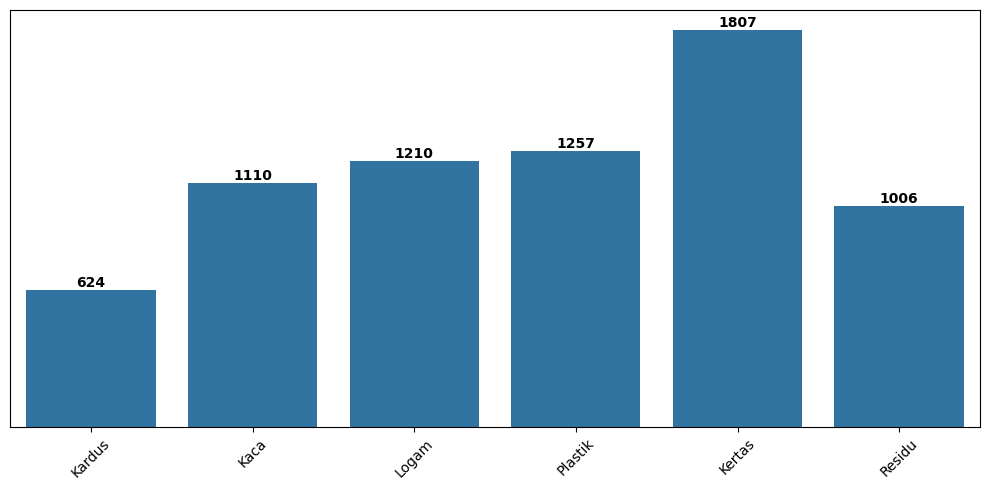

In [ ]:
kategori = []
jumlah_sampah = []

daftar_kategori_in_folder = os.listdir(path1)

for folder_kategori in daftar_kategori_in_folder:
  path_kategori_in_folder = os.path.join(path1, folder_kategori)

  if os.path.isdir(path_kategori_in_folder):
    jumlah = len(os.listdir(path_kategori_in_folder))

    kategori.append(folder_kategori)
    jumlah_sampah.append(jumlah)

plt.figure(figsize=(10,5)) # set ukuran plot
ax = sns.barplot(x=kategori, y=jumlah_sampah) # bar_chart dari library seaborn
plt.yticks([]) # ngilangin nilai di Y
plt.xticks(rotation=45) # rotasiin nilai yang ada di X
ax.bar_label(ax.containers[0], label_type='edge', color='black', fontweight='bold') # nulis nilai masing-masing sampah
plt.tight_layout()
plt.show()

## DATA WARNGLING



**GATHERING: BUAT DATAFRAME METADATA SEMUA GAMBAR**

In [ ]:
records = []
kategori_list = sorted([
    f for f in os.listdir(path1)
    if os.path.isdir(os.path.join(path1, f))
])

for kat in kategori_list:
    folder = os.path.join(path1, kat)
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        if os.path.isfile(fpath):
            records.append({
                'path'     : fpath,
                'filename' : fname,
                'label'    : kat,
                'extension': os.path.splitext(fname)[1].lower()
            })

df = pd.DataFrame(records)
print(f'Total data terkumpul : {len(df)} gambar')
print(f'Jumlah kategori      : {df["label"].nunique()}')
print()
print(df.head())

Total data terkumpul : 7014 gambar
Jumlah kategori      : 6

                                                path    filename label  \
0  /root/.cache/kagglehub/datasets/fathurrahmanal...  R_4312.jpg  Kaca   
1  /root/.cache/kagglehub/datasets/fathurrahmanal...  R_5063.jpg  Kaca   
2  /root/.cache/kagglehub/datasets/fathurrahmanal...  R_3973.jpg  Kaca   
3  /root/.cache/kagglehub/datasets/fathurrahmanal...  R_5431.jpg  Kaca   
4  /root/.cache/kagglehub/datasets/fathurrahmanal...  R_5358.jpg  Kaca   

  extension  
0      .jpg  
1      .jpg  
2      .jpg  
3      .jpg  
4      .jpg  


**ASSESSING: CEK FORMAT DAN EKSTENSI FILE**

In [ ]:
print('Distribusi ekstensi file:')
print(df['extension'].value_counts())
print()

valid_ext = ['.jpg', '.jpeg', '.png', '.bmp', '.webp']
invalid = df[~df['extension'].isin(valid_ext)]

if len(invalid) > 0:
    print(f'Ditemukan {len(invalid)} file dengan ekstensi tidak valid:')
    print(invalid[['filename', 'label', 'extension']])
else:
    print('Semua file memiliki ekstensi gambar yang valid.')

df = df[df['extension'].isin(valid_ext)].reset_index(drop=True)
print(f'\nTotal data setelah filter ekstensi: {len(df)}')

Distribusi ekstensi file:
extension
.jpg    7014
Name: count, dtype: int64

Semua file memiliki ekstensi gambar yang valid.

Total data setelah filter ekstensi: 7014


**ASSESSING: DETEKSI GAMBAR CORRUPT**

In [ ]:
corrupt_files = []
widths, heights = [], []

for idx, row in df.iterrows():
    try:
        with Image.open(row['path']) as img:
            img.verify()
        with Image.open(row['path']) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except Exception as e:
        corrupt_files.append({'path': row['path'], 'label': row['label'], 'error': str(e)})
        widths.append(None)
        heights.append(None)

df['width']  = widths
df['height'] = heights

print(f'Total file corrupt: {len(corrupt_files)}')

if corrupt_files:
    df_corrupt = pd.DataFrame(corrupt_files)
    print(df_corrupt)
    df = df[df['width'].notna()].reset_index(drop=True)
    print(f'Data setelah hapus corrupt: {len(df)}')
else:
    print('Tidak ada gambar yang corrupt.')

Total file corrupt: 0
Tidak ada gambar yang corrupt.


**ASSESSING: CEK DUPLIKAT**

In [ ]:
duplikat = df[df.duplicated(subset=['filename'], keep=False)]
print(f'Jumlah duplikat (berdasarkan filename): {len(duplikat)}')

if len(duplikat) > 0:
    print(duplikat[['filename', 'label']].head(10))
    df = df.drop_duplicates(subset=['filename']).reset_index(drop=True)
    print(f'Data setelah hapus duplikat: {len(df)}')
else:
    print('Tidak ada duplikat.')

print(f'\nTotal data bersih: {len(df)}') # ini kayaknya bisa coba metode lain buat cek duplikat

Jumlah duplikat (berdasarkan filename): 56
          filename    label
4758  Image_39.jpg  Plastik
4794  Image_16.jpg  Plastik
4801   Image_8.jpg  Plastik
4861  Image_27.jpg  Plastik
4863   Image_2.jpg  Plastik
4864  Image_58.jpg  Plastik
4987   Image_9.jpg  Plastik
5082  Image_43.jpg  Plastik
5115  Image_11.jpg  Plastik
5126  Image_50.jpg  Plastik
Data setelah hapus duplikat: 6986

Total data bersih: 6986


**CLEANING: DETEKSI DUPLIKAT BERDASARKAN HASH KONTEN FILE**

In [ ]:

# Hash-based duplicate detection (lebih akurat dari filename)
def file_hash(path, chunk=8192):
    h = hashlib.md5()
    try:
        with open(path, 'rb') as f:
            while True:
                data = f.read(chunk)
                if not data:
                    break
                h.update(data)
        return h.hexdigest()
    except Exception:
        return None

print("Menghitung hash file... (mungkin butuh beberapa menit)")
df['file_hash'] = df['path'].apply(file_hash)

dup_hash = df[df.duplicated(subset=['file_hash'], keep=False) & df['file_hash'].notna()]
print(f"Duplikat berdasarkan konten file (hash): {len(dup_hash)}")

if len(dup_hash) > 0:
    print(dup_hash[['filename', 'label', 'file_hash']].head(10))
    df = df.drop_duplicates(subset=['file_hash']).reset_index(drop=True)
    print(f"Data setelah hapus duplikat hash: {len(df)}")
else:
    print("Tidak ada duplikat konten.")


Menghitung hash file... (mungkin butuh beberapa menit)
Duplikat berdasarkan konten file (hash): 6
                filename    label                         file_hash
3894          R_1937.jpg    Logam  9afa46d5624b734119b6958e9a635595
4457          R_1884.jpg    Logam  9afa46d5624b734119b6958e9a635595
5823          R_1277.jpg  Plastik  79bd35d90c441cc30c504a386c74602c
5893            R_38.jpg  Plastik  79bd35d90c441cc30c504a386c74602c
6529   maxresdefault.jpg   Residu  e38703d2297792b9c0f7964a084b2af8
6763  maxresdefault2.jpg   Residu  e38703d2297792b9c0f7964a084b2af8
Data setelah hapus duplikat hash: 6983



## EXPLORATORY DATA ANALYSIS (EDA) DAN VISUALISASI

**DISTRIBUSI JUMLAH DATA PER KATEGORI**



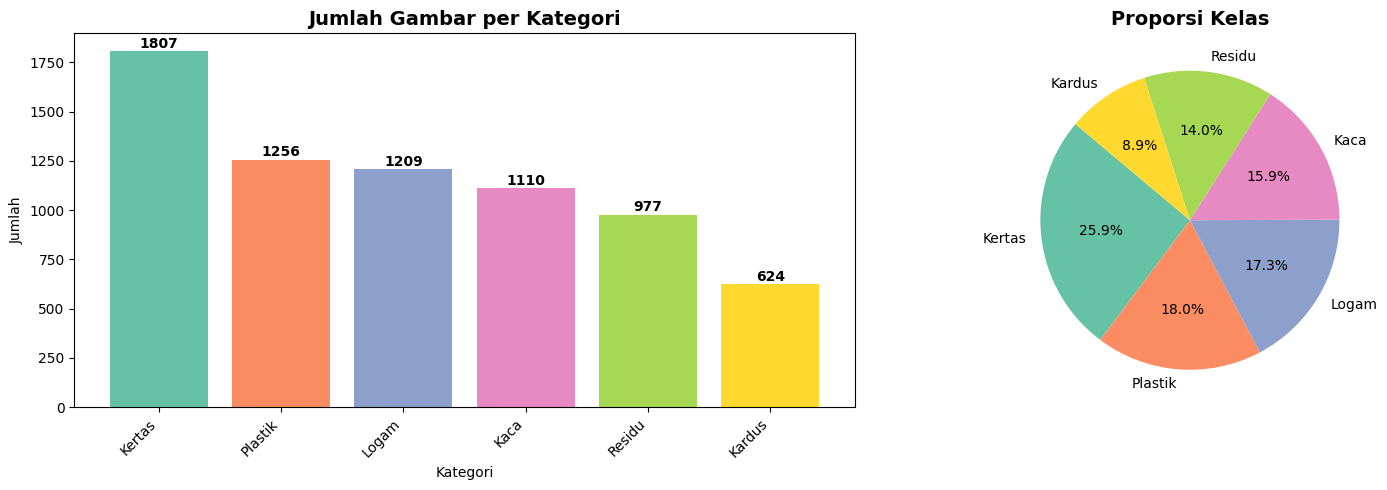


Rasio kelas terbanyak vs tersedikit: 2.90x
Distribusi kelas relatif seimbang.


In [ ]:
label_counts = df['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
bars = axes[0].bar(
    label_counts.index,
    label_counts.values,
    color=sns.color_palette('Set2', len(label_counts))
)
axes[0].set_title('Jumlah Gambar per Kategori', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kategori')
axes[0].set_ylabel('Jumlah')
axes[0].set_xticklabels(label_counts.index, rotation=45, ha='right')
for bar, val in zip(bars, label_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(val), ha='center', va='bottom', fontweight='bold'
    )

# Pie chart
axes[1].pie(
    label_counts.values,
    labels=label_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2', len(label_counts))
)
axes[1].set_title('Proporsi Kelas', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

rasio = label_counts.max() / label_counts.min()
print(f'\nRasio kelas terbanyak vs tersedikit: {rasio:.2f}x')
if rasio > 3:
    print('Terdapat class imbalance yang signifikan. Pertimbangkan augmentasi atau oversampling.')
else:
    print('Distribusi kelas relatif seimbang.')

**SAMPLE GAMBAR DARI SETIAP KATEGORI**

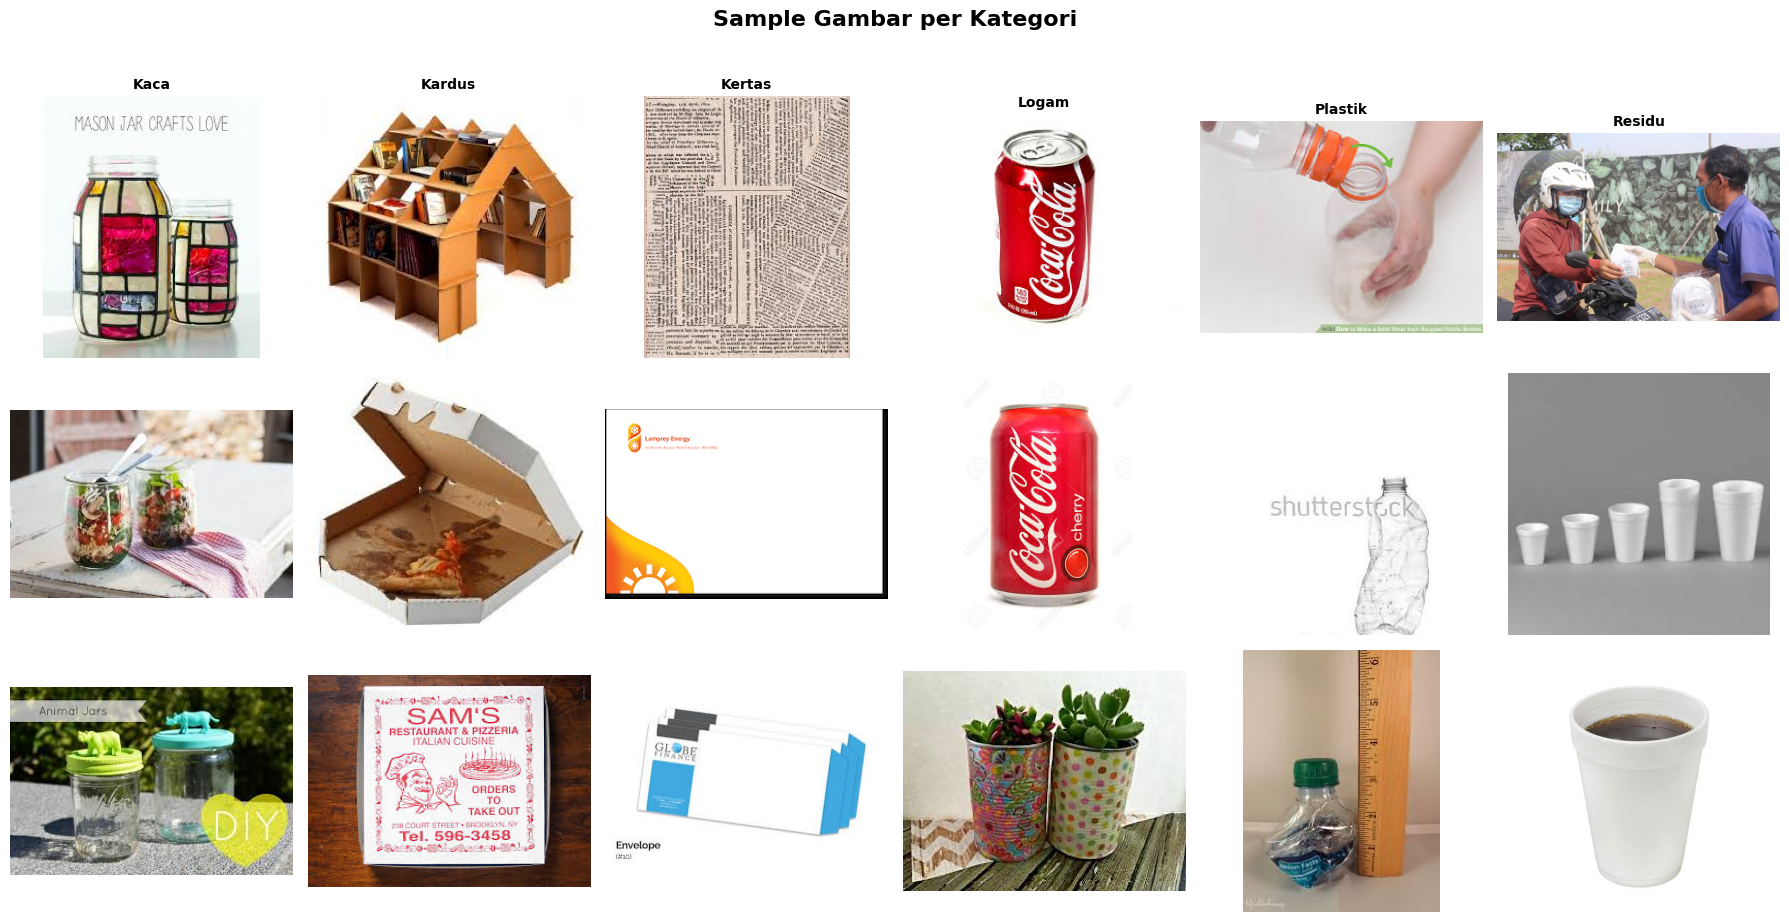

In [ ]:
n_sample = 3
n_kat    = len(kategori_list)

fig, axes = plt.subplots(n_sample, n_kat, figsize=(n_kat * 3, n_sample * 3))

for col_idx, kat in enumerate(kategori_list):
    sampel = df[df['label'] == kat].sample(
        min(n_sample, len(df[df['label'] == kat])),
        random_state=42
    )
    for row_idx, (_, row) in enumerate(sampel.iterrows()):
        ax = axes[row_idx][col_idx] if n_kat > 1 else axes[row_idx]
        try:
            img = Image.open(row['path']).convert('RGB')
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, 'Error', ha='center', va='center')
        ax.axis('off')
        if row_idx == 0:
            ax.set_title(kat, fontsize=10, fontweight='bold')

plt.suptitle('Sample Gambar per Kategori', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**DISTRIBUSI UKURAN GAMBAR (WIDTH, HEIGHT, ASPECT RATIO)**

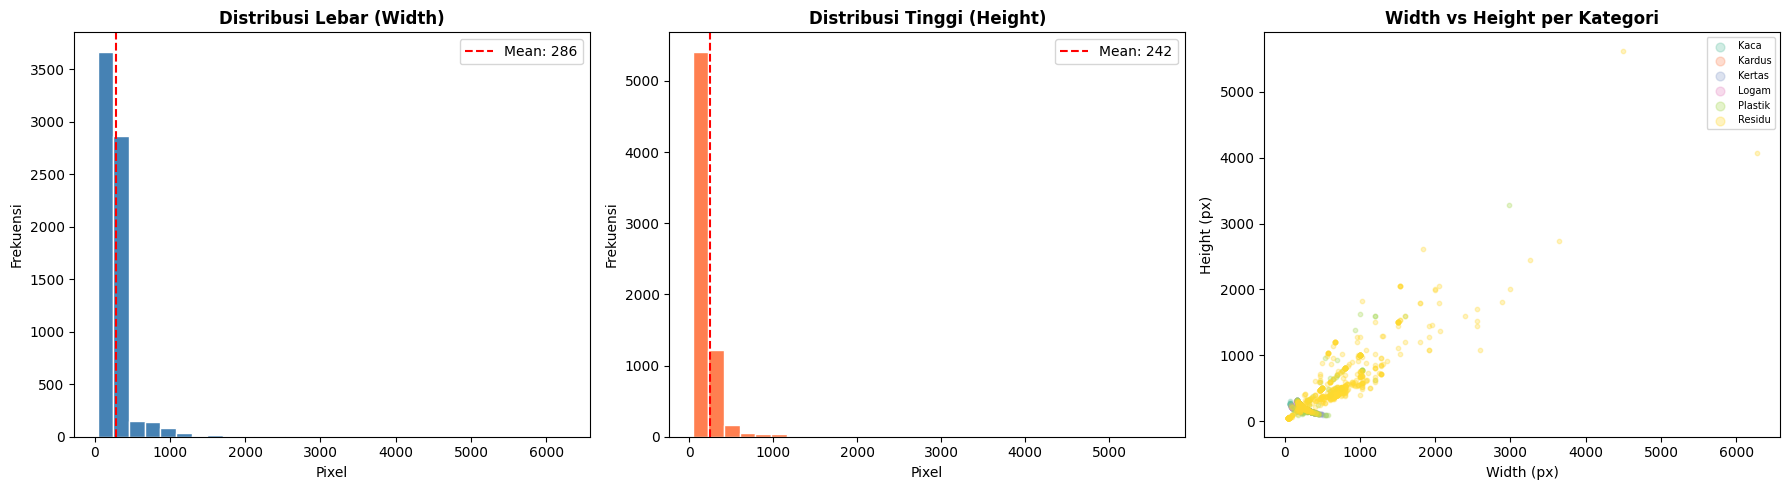

Statistik Ukuran Gambar:
         width   height  aspect_ratio
count  6983.00  6983.00       6983.00
mean    285.74   241.89          1.24
std     217.13   186.39          0.46
min      42.00    42.00          0.22
25%     225.00   183.00          1.00
50%     242.00   220.00          1.09
75%     275.00   225.00          1.50
max    6270.00  5625.00          6.47


In [ ]:
df['aspect_ratio'] = df['width'] / df['height']
df['total_pixels'] = df['width'] * df['height']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['width'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Lebar (Width)', fontweight='bold')
axes[0].set_xlabel('Pixel')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(
    df['width'].mean(), color='red', linestyle='--',
    label=f'Mean: {df["width"].mean():.0f}'
)
axes[0].legend()

axes[1].hist(df['height'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Distribusi Tinggi (Height)', fontweight='bold')
axes[1].set_xlabel('Pixel')
axes[1].set_ylabel('Frekuensi')
axes[1].axvline(
    df['height'].mean(), color='red', linestyle='--',
    label=f'Mean: {df["height"].mean():.0f}'
)
axes[1].legend()

colors = sns.color_palette('Set2', len(kategori_list))
for i, kat in enumerate(kategori_list):
    subset = df[df['label'] == kat]
    axes[2].scatter(subset['width'], subset['height'],
                    alpha=0.3, label=kat, color=colors[i], s=10)
axes[2].set_title('Width vs Height per Kategori', fontweight='bold')
axes[2].set_xlabel('Width (px)')
axes[2].set_ylabel('Height (px)')
axes[2].legend(fontsize=7, markerscale=2)

plt.tight_layout()
plt.show()

print('Statistik Ukuran Gambar:')
print(df[['width', 'height', 'aspect_ratio']].describe().round(2))

**DISTRIBUSI UKURAN PER KATEGORI (BOXPLOT)**

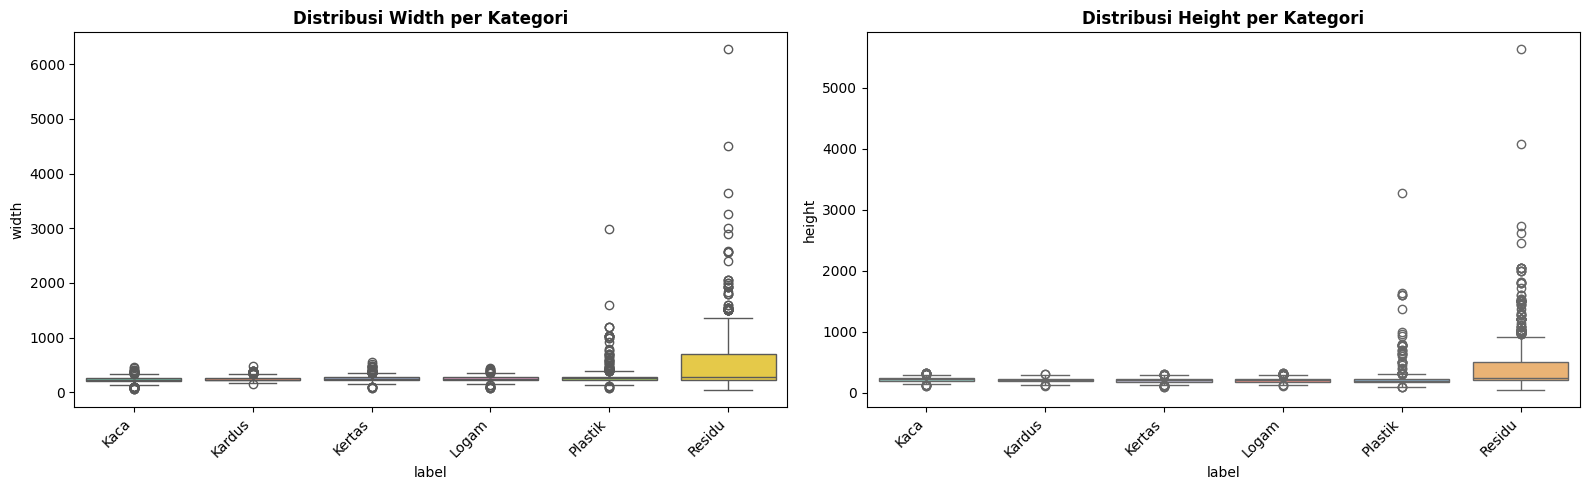

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df, x='label', y='width',  palette='Set2', ax=axes[0])
axes[0].set_title('Distribusi Width per Kategori', fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

sns.boxplot(data=df, x='label', y='height', palette='Set3', ax=axes[1])
axes[1].set_title('Distribusi Height per Kategori', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

**EDA: ANALISIS STATISTIK WARNA (RGB MEAN & STD PER KATEGORI)**

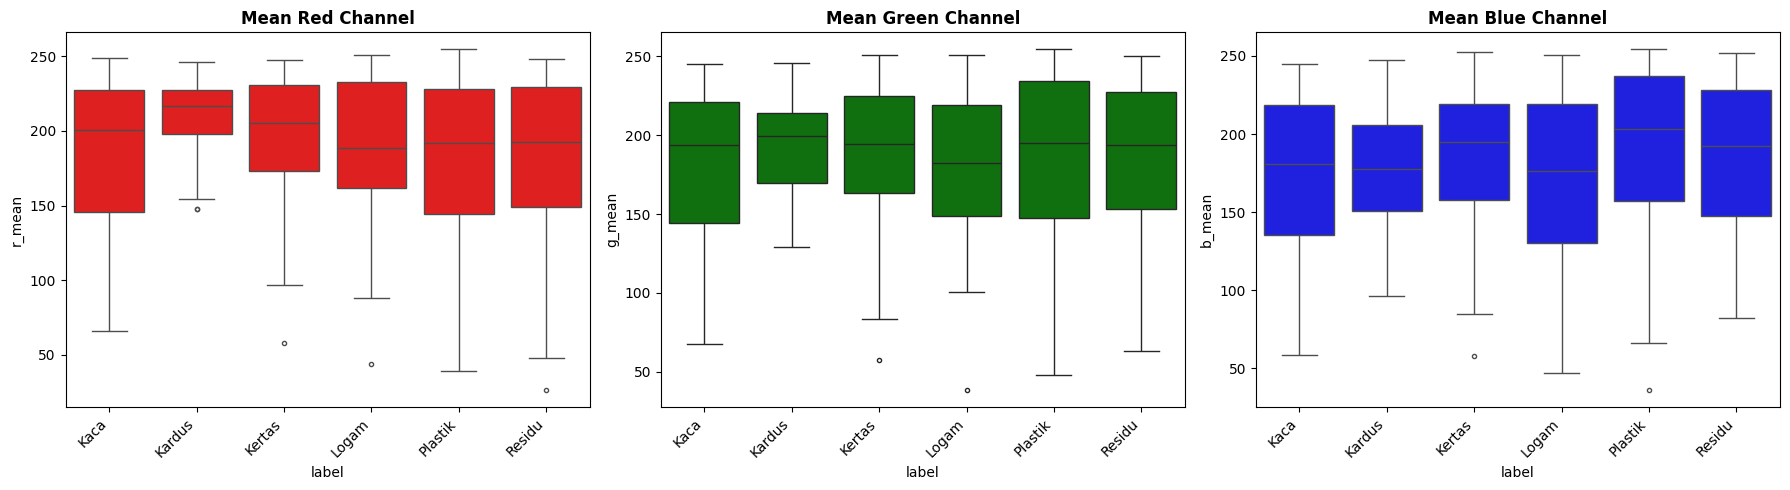

In [ ]:

# Sample max 50 per kategori agar tidak terlalu lama
sample_records = []
for kat in kategori_list:
    subset = df[df['label'] == kat].sample(min(50, len(df[df['label'] == kat])), random_state=42)
    sample_records.append(subset)

df_sample = pd.concat(sample_records).reset_index(drop=True)

r_means, g_means, b_means = [], [], []
r_stds,  g_stds,  b_stds  = [], [], []

for _, row in df_sample.iterrows():
    try:
        img = np.array(Image.open(row['path']).convert('RGB').resize((64, 64)))
        r_means.append(img[:,:,0].mean())
        g_means.append(img[:,:,1].mean())
        b_means.append(img[:,:,2].mean())
        r_stds.append(img[:,:,0].std())
        g_stds.append(img[:,:,1].std())
        b_stds.append(img[:,:,2].std())
    except Exception:
        for lst in [r_means, g_means, b_means, r_stds, g_stds, b_stds]:
            lst.append(np.nan)

df_sample = df_sample.copy()
df_sample['r_mean'] = r_means
df_sample['g_mean'] = g_means
df_sample['b_mean'] = b_means
df_sample['r_std']  = r_stds
df_sample['g_std']  = g_stds
df_sample['b_std']  = b_stds
df_sample['brightness'] = (df_sample['r_mean'] + df_sample['g_mean'] + df_sample['b_mean']) / 3

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, channel, color, title in zip(
        axes,
        ['r_mean', 'g_mean', 'b_mean'],
        ['red', 'green', 'blue'],
        ['Mean Red Channel', 'Mean Green Channel', 'Mean Blue Channel']):
    sns.boxplot(data=df_sample, x='label', y=channel, ax=ax, color=color, fliersize=3)
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


## MENYIAPKAN DATASET AKHIR (TRAIN / VALIDATION / TEST SPLIT)

Ukuran split:
  Train :  4888 gambar (70.0%)
  Val   :   698 gambar (10.0%)
  Test  :  1397 gambar (20.0%)


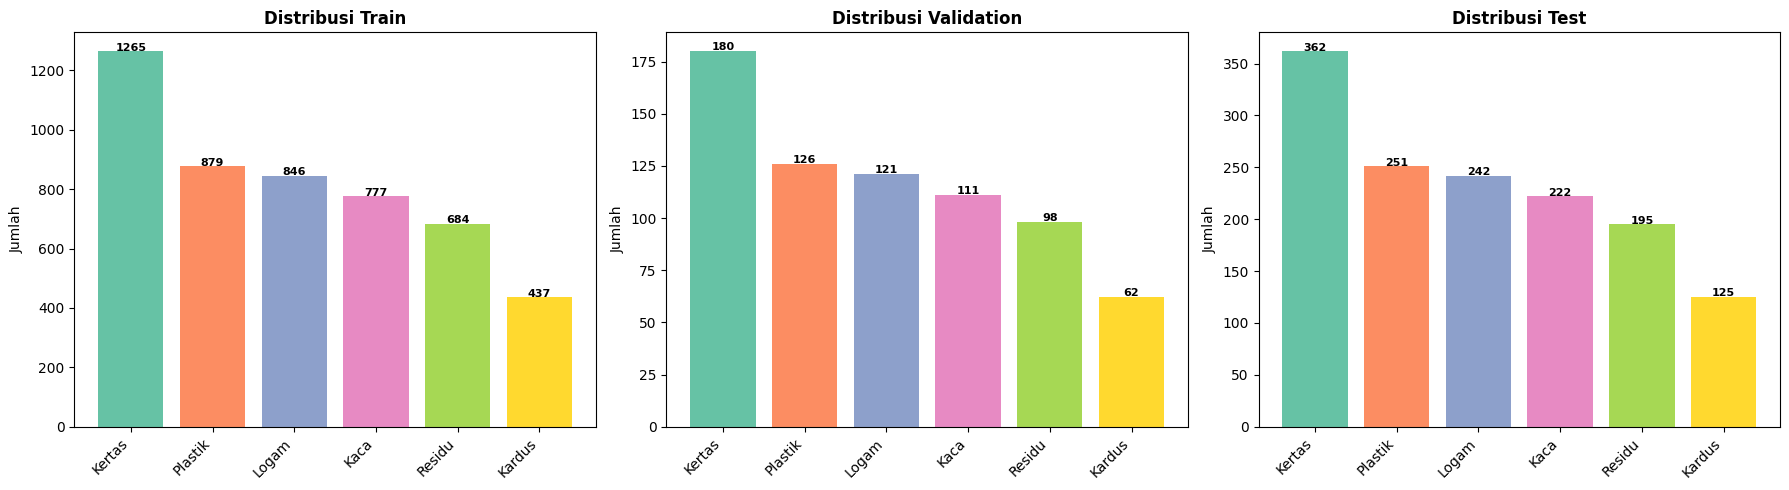

In [ ]:
# Split: 70% train, 10 val, 20% test
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.6667, random_state=42, stratify=temp_df['label']
)

print("Ukuran split:")
print(f"  Train : {len(train_df):>5} gambar ({len(train_df)/len(df)*100:.1f}%)")
print(f"  Val   : {len(val_df):>5} gambar ({len(val_df)/len(df)*100:.1f}%)")
print(f"  Test  : {len(test_df):>5} gambar ({len(test_df)/len(df)*100:.1f}%)")

# Cek distribusi per split
splits = {'Train': train_df, 'Validation': val_df, 'Test': test_df}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, split) in zip(axes, splits.items()):
    counts = split['label'].value_counts()
    ax.bar(counts.index, counts.values, color=sns.color_palette('Set2', len(counts)))
    ax.set_title(f'Distribusi {name}', fontweight='bold')
    ax.set_xticklabels(counts.index, rotation=45, ha='right')
    ax.set_ylabel('Jumlah')
    for i, (idx, val) in enumerate(counts.items()):
        ax.text(i, val + 0.5, str(val), ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
import shutil

# Buat struktur folder train / val / test
base_output = 'dataset_split'

for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    for kat in split_df['label'].unique():
        folder = os.path.join(base_output, split_name, kat)
        os.makedirs(folder, exist_ok=True)

    for _, row in split_df.iterrows():
        dst = os.path.join(base_output, split_name, row['label'], row['filename'])
        shutil.copy2(row['path'], dst)

    print(f"{split_name}: {len(split_df)} gambar disalin ke '{base_output}/{split_name}/'")

print()
print("Struktur folder hasil split:")
for split_name in ['train', 'val', 'test']:
    split_path = os.path.join(base_output, split_name)
    total = sum(len(files) for _, _, files in os.walk(split_path))
    print(f"  {base_output}/{split_name}/  → {total} gambar")
    for kat in sorted(os.listdir(split_path)):
        n = len(os.listdir(os.path.join(split_path, kat)))
        print(f"    └── {kat}/  ({n} gambar)")


train: 4888 gambar disalin ke 'dataset_split/train/'
val: 698 gambar disalin ke 'dataset_split/val/'
test: 1397 gambar disalin ke 'dataset_split/test/'

Struktur folder hasil split:
  dataset_split/train/  → 4888 gambar
    └── Kaca/  (777 gambar)
    └── Kardus/  (437 gambar)
    └── Kertas/  (1265 gambar)
    └── Logam/  (846 gambar)
    └── Plastik/  (879 gambar)
    └── Residu/  (684 gambar)
  dataset_split/val/  → 698 gambar
    └── Kaca/  (111 gambar)
    └── Kardus/  (62 gambar)
    └── Kertas/  (180 gambar)
    └── Logam/  (121 gambar)
    └── Plastik/  (126 gambar)
    └── Residu/  (98 gambar)
  dataset_split/test/  → 1397 gambar
    └── Kaca/  (222 gambar)
    └── Kardus/  (125 gambar)
    └── Kertas/  (362 gambar)
    └── Logam/  (242 gambar)
    └── Plastik/  (251 gambar)
    └── Residu/  (195 gambar)


In [ ]:
folder_path = '/content/dataset_split'
output_path = 'dataset_klasifikasi'

shutil.make_archive(output_path, 'zip', folder_path)

print("Berhasil membuat file ZIP:", output_path + '.zip')

Berhasil membuat file ZIP: dataset_klasifikasi.zip


# Data Dictionary — Dataset Klasifikasi Sampah

**Sumber dataset:** `fathurrahmanalfarizy/sampah-daur-ulang` (Kaggle)  
**Jumlah kelas:** 6  
**Split:** Train 70% / Validasi 10% / Test 20%

---

## Kelas 1 — Kaca

**Nama folder:** `Kaca`   
**Deskripsi:** Sampah berbahan kaca atau material transparan/tembus cahaya yang tidak menyerap cairan. Dapat didaur ulang dengan cara dilebur dan dibentuk ulang tanpa kehilangan kualitas.


## Kelas 2 — Kardus

**Nama folder:** `Kardus`   
**Deskripsi:** Sampah kertas tebal berlapis atau bergelombang yang umumnya digunakan sebagai kemasan produk. Dapat didaur ulang menjadi kertas atau kardus baru.


## Kelas 3 — Kertas

**Nama folder:** `Kertas`  
**Deskripsi:** Sampah berbahan selulosa tipis, lebih ringan dari kardus. Dapat didaur ulang menjadi kertas baru, namun kualitas menurun setiap daur ulang.


## Kelas 4 — Logam

**Nama folder:** `Logam`  
**Deskripsi:** Sampah berbahan metal yang dapat dilelehkan dan dibentuk ulang berkali-kali tanpa kehilangan sifat asalnya. Nilai ekonomi daur ulang tinggi.


## Kelas 5 — Plastik

**Nama folder:** `Plastik`  
**Deskripsi:** Sampah berbahan polimer sintetis ringan. Mencakup berbagai jenis kode daur ulang (PET, HDPE, PVC, PP, dll). Paling banyak ditemukan di lingkungan.


## Kelas 6 — Residu

**Nama folder:** `Residu`  
**Deskripsi:** Sampah yang tidak termasuk dalam 5 kategori di atas dan **tidak dapat didaur ulang** dengan mudah. Umumnya dikirim ke TPA (tempat pembuangan akhir) atau dibakar.

